<a href="https://colab.research.google.com/github/Atharv-1905/Deep-Learning/blob/main/DL_LAB_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, BatchNormalization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
print("\n--- Starting Part 2: CIFAR-10 with CNN ---")

# a) Perform Data Pre-processing (CIFAR-10)
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = datasets.cifar10.load_data()




--- Starting Part 2: CIFAR-10 with CNN ---


In [ ]:
# Scale pixel values to be between 0 and 1
X_train_cifar = X_train_cifar / 255.0
X_test_cifar = X_test_cifar / 255.0



In [ ]:
# Flatten labels to a 1D array for easier matrix evaluation
y_train_cifar = y_train_cifar.flatten()
y_test_cifar = y_test_cifar.flatten()



In [ ]:
model = Sequential()

# Layer 1
model.add(Conv2D(96, kernel_size=(3,3), strides=(1,1), input_shape=(32,32,3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# Layer 2
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# Layer 3
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))

# Layer 4
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))

# Layer 5
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer 1
model.add(Dense(1024))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Fully Connected Layer 2
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10))
model.add(Activation('softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# b) Define Model and perform training (CNN)
# cnn_model = models.Sequential([
#     layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
#     layers.MaxPooling2D((2, 2)),
#     layers.Dropout(0.2),
#     layers.Conv2D(64, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Dropout(0.2),
#     layers.Flatten(),
#     layers.Dense(64, activation='relu'),
#     layers.Dense(10, activation='softmax')
# ])



In [ ]:
model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [ ]:
print("\nTraining CNN on CIFAR-10...")
# Convert integer labels to one-hot encoded labels
num_classes = 10  # CIFAR-10 has 10 classes
y_train_cifar_one_hot = tf.keras.utils.to_categorical(y_train_cifar, num_classes)
history = model.fit(X_train_cifar, y_train_cifar_one_hot, epochs=10, validation_split=0.1, batch_size=32, verbose=1)


Training CNN on CIFAR-10...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.8290 - loss: 0.5323 - val_accuracy: 0.7436 - val_loss: 0.8601
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.8335 - loss: 0.5147 - val_accuracy: 0.7486 - val_loss: 0.8132
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.8472 - loss: 0.4821 - val_accuracy: 0.7076 - val_loss: 0.9564
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.8536 - loss: 0.4607 - val_accuracy: 0.6828 - val_loss: 1.1515
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.8669 - loss: 0.4235 - val_accuracy: 0.6940 - val_loss: 1.1922
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.8669 - loss: 0.4201 - val_accuracy: 0.7230 - val_loss: 1.0982
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.8738 - loss: 0.4166 - val_accuracy: 0.7524 - val_loss: 1.0082
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 1

In [ ]:
num_classes = 10 # CIFAR-10 has 10 classes
y_test_cifar_one_hot = tf.keras.utils.to_categorical(y_test_cifar, num_classes)
test_loss, test_acc = model.evaluate(X_test_cifar, y_test_cifar_one_hot, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7139


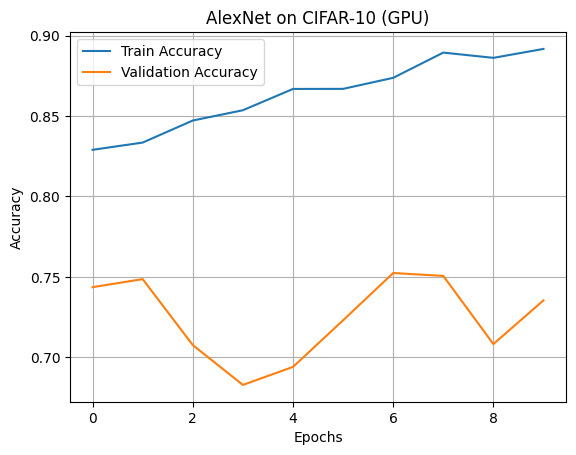

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('AlexNet on CIFAR-10 (GPU)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()